# Fanta Manager image generator

This notebook reads the images placed directly in `../img`, converts JPG/JPEG/PNG/WEBP files to normalized PNG images, and optionally sends them to a Hugging Face image-to-image model to create football-cover portraits.

> The remote provider receives the source images. Use only images you are authorized to upload. Hugging Face free accounts include limited monthly inference credits; the service is not unlimited. Generation is disabled by default to avoid accidental requests.

In [1]:
%pip install -q -U huggingface_hub Pillow python-dotenv pandas tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import time
from getpass import getpass
from pathlib import Path

import pandas as pd
from PIL import Image, ImageOps
from dotenv import load_dotenv
from huggingface_hub import InferenceClient
from IPython.display import display
from tqdm.auto import tqdm

# Resolve src/ whether Jupyter starts from src/notebooks or the repository root.
working_dir = Path.cwd().resolve()
if working_dir.name == "notebooks":
    src_dir = working_dir.parent
elif (working_dir / "src" / "notebooks").exists():
    src_dir = working_dir / "src"
else:
    raise RuntimeError("Run this notebook from src/notebooks or from the repository root.")

input_dir = src_dir / "img"
normalized_dir = input_dir / "fanta_managers_normalized"
generated_dir = input_dir / "fanta_managers_generated"
manifest_path = generated_dir / "generation_manifest.csv"

supported_extensions = {".jpg", ".jpeg", ".png", ".webp"}
max_image_side = 1536
model_id = "black-forest-labs/FLUX.1-Kontext-dev"
provider = "auto"
max_retries = 3
request_pause_seconds = 1
overwrite_outputs = False
run_generation = True  # Change to True only after adding images and configuring HF_TOKEN.

prompt = (
    "Transform the person in the reference image into a professional football manager "
    "featured on a premium collectible football sticker. Preserve the person's exact "
    "recognizable facial identity, facial structure, hairstyle, skin tone, beard, glasses "
    "and distinctive features. Dress the person as a head coach in an elegant dark tailored "
    "suit, crisp white shirt and formal tie. Show a confident waist-up portrait, facing the "
    "camera with a composed and authoritative expression, optionally with arms crossed. "
    "Place the manager near the touchline of a softly blurred football stadium. Use the "
    "visual language of a classic Italian football collectible sticker: vertical composition, "
    "clean decorative border, balanced centered framing, vivid but realistic colors, subtle "
    "glossy printed-card texture and polished studio sports photography. Keep the same visual "
    "template and framing for every manager in the collection. Include a clean blank nameplate "
    "area at the bottom, but do not generate any text. Do not add football kits, sportswear, "
    "brand names, team crests, sponsor logos, trademarks, watermarks, trophies, extra people, "
    "duplicated facial features, duplicated limbs or distorted anatomy."
)

input_dir.mkdir(parents=True, exist_ok=True)
normalized_dir.mkdir(parents=True, exist_ok=True)
generated_dir.mkdir(parents=True, exist_ok=True)
load_dotenv(src_dir / ".env")

print(f"Input directory: {input_dir}")
print(f"Generated images: {generated_dir}")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Input directory: /Users/gianlucapanzani/Desktop/Fantacalcio/src/img
Generated images: /Users/gianlucapanzani/Desktop/Fantacalcio/src/img/fanta_managers_generated


In [3]:
def safe_stem(value: str) -> str:
    normalized_value = re.sub(r"[^A-Za-z0-9._-]+", "_", value).strip("._")
    return normalized_value or "image"


def list_source_images(directory: Path) -> list[Path]:
    return sorted(
        path
        for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in supported_extensions
    )


def normalize_to_png(source_path: Path) -> Path:
    output_name = f"{safe_stem(source_path.stem)}__{source_path.suffix[1:].lower()}.png"
    output_path = normalized_dir / output_name

    with Image.open(source_path) as source_image:
        image = ImageOps.exif_transpose(source_image)
        if "A" in image.getbands():
            rgba_image = image.convert("RGBA")
            white_background = Image.new("RGBA", rgba_image.size, (255, 255, 255, 255))
            image = Image.alpha_composite(white_background, rgba_image).convert("RGB")
        else:
            image = image.convert("RGB")

        image.thumbnail((max_image_side, max_image_side), Image.Resampling.LANCZOS)
        image.save(output_path, format="PNG", optimize=True)

    return output_path


source_images = list_source_images(input_dir)
normalization_records = []

for source_path in source_images:
    try:
        normalized_path = normalize_to_png(source_path)
        normalization_records.append({
            "source": str(source_path),
            "normalized": str(normalized_path),
            "status": "converted",
            "error": "",
        })
    except (OSError, ValueError) as error:
        normalization_records.append({
            "source": str(source_path),
            "normalized": "",
            "status": "conversion_error",
            "error": str(error),
        })

normalization_df = pd.DataFrame(
    normalization_records,
    columns=["source", "normalized", "status", "error"],
)

if normalization_df.empty:
    print(f"No JPG, JPEG, PNG or WEBP images found in {input_dir}.")
else:
    display(normalization_df)

,source,normalized,status,error
0,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,converted,
1,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,converted,
2,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,converted,
3,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,converted,


In [4]:
def create_inference_client() -> InferenceClient:
    hf_token = os.getenv("HF_TOKEN")
    if not hf_token:
        hf_token = getpass("Hugging Face token (not stored by the notebook): " ).strip()
    if not hf_token:
        raise RuntimeError(
            "HF_TOKEN is required. Create a token with Inference Providers permission "
            "and export it before running this cell."
        )
    return InferenceClient(provider=provider, api_key=hf_token)


def generate_football_cover(
        client: InferenceClient,
        input_path: Path,
        output_path: Path,
) -> None:
    input_image = input_path.read_bytes()

    for attempt in range(1, max_retries + 1):
        try:
            generated_image = client.image_to_image(
                input_image,
                prompt=prompt,
                model=model_id,
            )
            generated_image.convert("RGB").save(output_path, format="PNG", optimize=True)
            return
        except Exception:
            if attempt == max_retries:
                raise
            time.sleep(2 ** attempt)


In [5]:
generation_records = []
converted_images = (
    normalization_df.loc[normalization_df["status"].eq("converted"), "normalized"].tolist()
    if not normalization_df.empty
    else []
)

if not run_generation:
    print("Generation disabled. Set run_generation = True in the configuration cell when ready.")
elif not converted_images:
    print("No normalized images are available for generation.")
else:
    client = create_inference_client()

    for normalized_value in tqdm(converted_images, desc="Generating football covers"):
        normalized_path = Path(normalized_value)
        output_path = generated_dir / f"{normalized_path.stem}_football_cover.png"

        if output_path.exists() and not overwrite_outputs:
            generation_records.append({
                "input": str(normalized_path),
                "output": str(output_path),
                "model": model_id,
                "status": "skipped_existing",
                "error": "",
            })
            continue

        try:
            generate_football_cover(client, normalized_path, output_path)
            generation_records.append({
                "input": str(normalized_path),
                "output": str(output_path),
                "model": model_id,
                "status": "generated",
                "error": "",
            })
        except Exception as error:
            generation_records.append({
                "input": str(normalized_path),
                "output": str(output_path),
                "model": model_id,
                "status": "generation_error",
                "error": str(error),
            })

        time.sleep(request_pause_seconds)

generation_df = pd.DataFrame(
    generation_records,
    columns=["input", "output", "model", "status", "error"],
)
if not generation_df.empty:
    generation_df.to_csv(manifest_path, index=False)
    display(generation_df)

Generating football covers:   0%|          | 0/4 [00:00<?, ?it/s]

,input,output,model,status,error
0,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,black-forest-labs/FLUX.1-Kontext-dev,generated,
1,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,black-forest-labs/FLUX.1-Kontext-dev,generated,
2,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,black-forest-labs/FLUX.1-Kontext-dev,generated,
3,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,/Users/gianlucapanzani/Desktop/Fantacalcio/src...,black-forest-labs/FLUX.1-Kontext-dev,generation_error,Client error '402 Payment Required' for url 'h...


Screenshot_2026-09-09_alle_16.05.22__png_football_cover.png


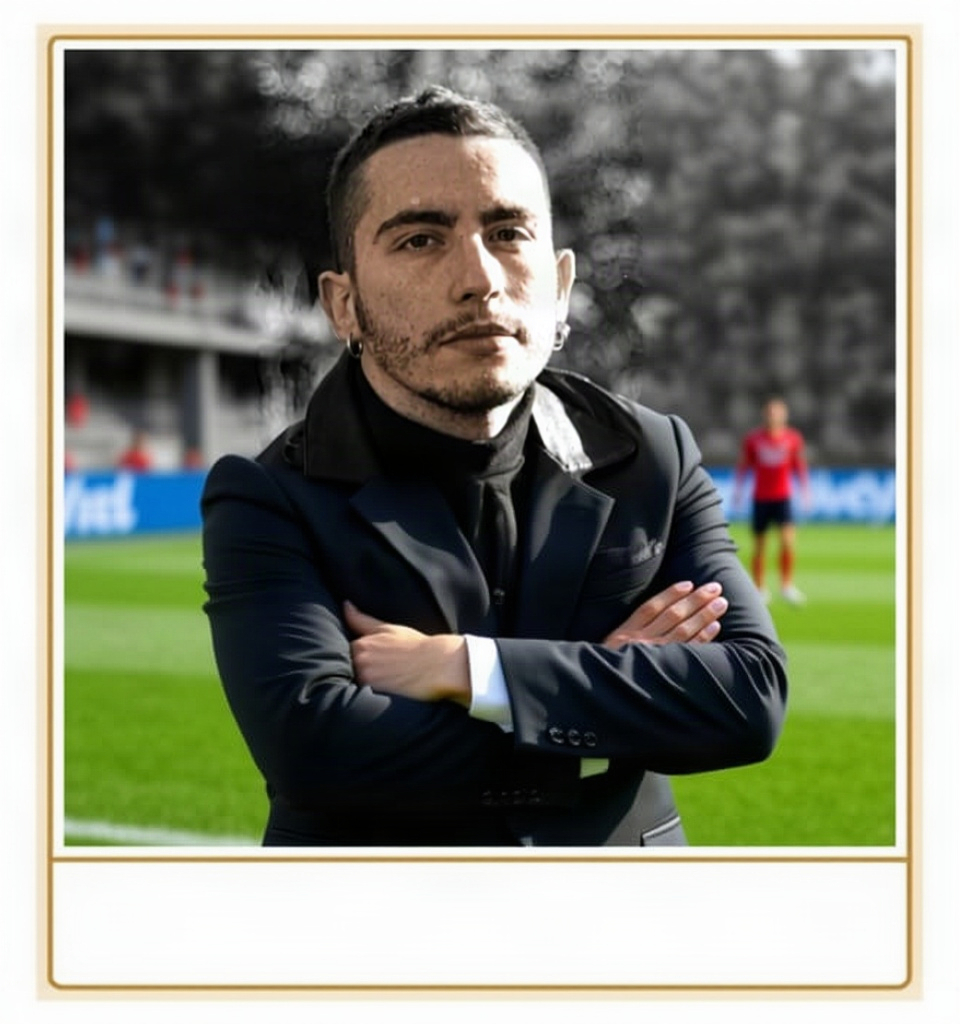

Screenshot_2026-09-09_alle_16.08.11__png_football_cover.png


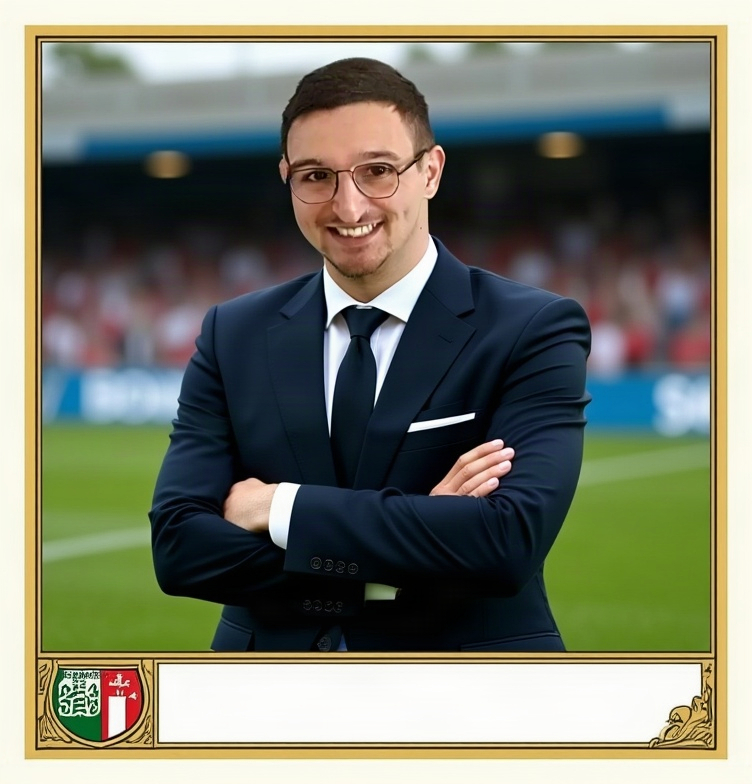

Screenshot_2026-09-09_alle_16.09.42__png_football_cover.png


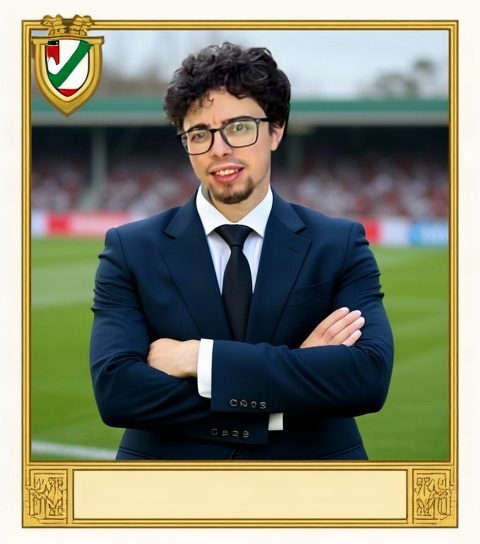

In [6]:
generated_images = sorted(generated_dir.glob("*_football_cover.png"))
if not generated_images:
    print("No generated covers to preview yet.")
else:
    for generated_path in generated_images:
        print(generated_path.name)
        display(Image.open(generated_path).copy())